Entendendo o problema

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import json

In [2]:
dados = pd.read_json('dados/dataset-telecon.json')

In [3]:
dados.head()

,id_cliente,Churn,cliente,telefone,internet,conta
0,0002-ORFBO,nao,"{'genero': 'feminino', 'idoso': 0, 'parceiro':...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'DSL', 'seguranca_online'...","{'contrato': None, 'faturamente_eletronico': N..."
1,0003-MKNFE,nao,"{'genero': 'masculino', 'idoso': 0, 'parceiro'...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'DSL', 'seguranca_online'...","{'contrato': 'mes a mes', 'faturamente_eletron..."
2,0004-TLHLJ,sim,"{'genero': 'masculino', 'idoso': 0, 'parceiro'...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'fibra otica', 'seguranca...","{'contrato': 'mes a mes', 'faturamente_eletron..."
3,0011-IGKFF,sim,"{'genero': 'masculino', 'idoso': 1, 'parceiro'...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'fibra otica', 'seguranca...","{'contrato': 'mes a mes', 'faturamente_eletron..."
4,0013-EXCHZ,sim,"{'genero': 'feminino', 'idoso': 1, 'parceiro':...","{'servico_telefone': 'sim', 'varias_linhas': '...","{'servico_internet': 'fibra otica', 'seguranca...","{'contrato': 'mes a mes', 'faturamente_eletron..."


In [4]:
pd.json_normalize(dados['conta']).head()

,contrato,faturamente_eletronico,metodo_pagamento,cobranca.mensal,cobranca.Total
0,NaN,NaN,NaN,NaN,NaN
1,mes a mes,nao,cheque pelo correio,59.9,542.4
2,mes a mes,sim,cheque eletronico,73.9,280.85
3,mes a mes,sim,cheque eletronico,98.0,1237.85
4,mes a mes,sim,cheque pelo correio,83.9,267.4


In [5]:
with open('dados/dataset-telecon.json') as f:
    json_bruto = json.load(f)

In [6]:
dados_normalizados = pd.json_normalize(json_bruto)

In [7]:
dados_normalizados.head()

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0002-ORFBO,nao,feminino,0,sim,sim,9.0,sim,nao,DSL,...,sim,nao,sim,sim,nao,NaN,NaN,NaN,NaN,NaN
1,0003-MKNFE,nao,masculino,0,nao,nao,9.0,sim,sim,DSL,...,nao,nao,nao,nao,sim,mes a mes,nao,cheque pelo correio,59.9,542.4
2,0004-TLHLJ,sim,masculino,0,nao,nao,4.0,sim,nao,fibra otica,...,nao,sim,nao,nao,nao,mes a mes,sim,cheque eletronico,73.9,280.85
3,0011-IGKFF,sim,masculino,1,sim,nao,13.0,sim,nao,fibra otica,...,sim,sim,nao,sim,sim,mes a mes,sim,cheque eletronico,98.0,1237.85
4,0013-EXCHZ,sim,feminino,1,sim,nao,3.0,sim,nao,fibra otica,...,nao,nao,sim,sim,nao,mes a mes,sim,cheque pelo correio,83.9,267.4


In [8]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     7344 non-null   str    
 1   Churn                          7344 non-null   str    
 2   cliente.genero                 7344 non-null   str    
 3   cliente.idoso                  7344 non-null   int64  
 4   cliente.parceiro               7344 non-null   str    
 5   cliente.dependentes            7344 non-null   str    
 6   cliente.tempo_servico          7336 non-null   float64
 7   telefone.servico_telefone      7344 non-null   str    
 8   telefone.varias_linhas         7344 non-null   str    
 9   internet.servico_internet      7344 non-null   str    
 10  internet.seguranca_online      7344 non-null   str    
 11  internet.backup_online         7344 non-null   str    
 12  internet.protecao_dispositivo  7344 non-null   str    
 13 

In [9]:
idx = dados_normalizados[dados_normalizados['conta.cobranca.Total'] == ' '].index

In [10]:
idx

Index([975, 1775, 1955, 2075, 2232, 2308, 2930, 3134, 3203, 4169, 5599], dtype='int64')

In [11]:
dados_normalizados['conta.cobranca.Total'] = pd.to_numeric(dados_normalizados['conta.cobranca.Total'], errors='coerce')

In [12]:
dados_normalizados.info()

<class 'pandas.DataFrame'>
RangeIndex: 7344 entries, 0 to 7343
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   id_cliente                     7344 non-null   str    
 1   Churn                          7344 non-null   str    
 2   cliente.genero                 7344 non-null   str    
 3   cliente.idoso                  7344 non-null   int64  
 4   cliente.parceiro               7344 non-null   str    
 5   cliente.dependentes            7344 non-null   str    
 6   cliente.tempo_servico          7336 non-null   float64
 7   telefone.servico_telefone      7344 non-null   str    
 8   telefone.varias_linhas         7344 non-null   str    
 9   internet.servico_internet      7344 non-null   str    
 10  internet.seguranca_online      7344 non-null   str    
 11  internet.backup_online         7344 non-null   str    
 12  internet.protecao_dispositivo  7344 non-null   str    
 13 

In [13]:
dados_normalizados.loc[idx, 'conta.cobranca.Total'] = dados_normalizados.loc[idx, 'conta.cobranca.mensal'] * 24

In [14]:
dados_sem_vazio = dados_normalizados.loc[dados_normalizados['Churn'] != '', :].copy()

In [15]:
dados_sem_vazio.reset_index(drop=True, inplace=True)

Dados duplicados

In [16]:
dados_sem_vazio.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7113     True
7114     True
7115     True
7116     True
7117     True
Length: 7118, dtype: bool

In [17]:
dados_sem_vazio.drop_duplicates(inplace=True)

Dados nulos

Como verificar a quantidade amostras nulas

In [18]:
dados_sem_vazio.isna().sum().sum()

np.int64(114)

Como verificar a quantidade de valores nulos presentes

In [19]:
dados_sem_vazio[dados_sem_vazio.isna().any(axis=1)].head()

,id_cliente,Churn,cliente.genero,cliente.idoso,cliente.parceiro,cliente.dependentes,cliente.tempo_servico,telefone.servico_telefone,telefone.varias_linhas,internet.servico_internet,...,internet.backup_online,internet.protecao_dispositivo,internet.suporte_tecnico,internet.tv_streaming,internet.filmes_streaming,conta.contrato,conta.faturamente_eletronico,conta.metodo_pagamento,conta.cobranca.mensal,conta.cobranca.Total
0,0002-ORFBO,nao,feminino,0,sim,sim,9.0,sim,nao,DSL,...,sim,nao,sim,sim,nao,NaN,NaN,NaN,NaN,NaN
9,0016-QLJIS,nao,feminino,0,sim,sim,NaN,sim,sim,DSL,...,sim,sim,sim,sim,sim,dois anos,sim,cheque pelo correio,90.45,5957.90
176,0282-NVSJS,nao,feminino,1,sim,sim,NaN,nao,sem servico de telefone,DSL,...,nao,nao,sim,nao,nao,mes a mes,sim,cheque pelo correio,29.30,355.90
181,0295-QVKPB,nao,masculino,0,nao,nao,NaN,sim,nao,DSL,...,nao,sim,sim,sim,nao,mes a mes,sim,cartao de credito (automatico),63.95,318.10
437,0639-TSIQW,sim,feminino,0,nao,nao,67.0,sim,sim,fibra otica,...,sim,sim,nao,sim,nao,NaN,NaN,cartao de credito (automatico),NaN,6886.25


In [20]:
filtro = dados_sem_vazio['cliente.tempo_servico'].isna()

In [21]:
dados_sem_vazio[filtro][['cliente.tempo_servico', 'conta.cobranca.mensal', 'conta.cobranca.Total']]

,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
9,NaN,90.45,5957.90
176,NaN,29.30,355.90
181,NaN,63.95,318.10
751,NaN,101.05,5971.25
3523,NaN,76.10,1054.80
5273,NaN,20.60,116.60
5276,NaN,73.85,3581.40
6134,NaN,69.05,1958.45


In [22]:
dados_sem_vazio['cliente.tempo_servico'].fillna(
    np.ceil(
        dados_sem_vazio['conta.cobranca.Total'] / dados_sem_vazio['conta.cobranca.mensal']
    ), inplace=True
)

C:\Users\logistica.wms\AppData\Local\Temp\ipykernel_996\3942568079.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dados_sem_vazio['cliente.tempo_servico'].fillna(


0        9.0
1        9.0
2        4.0
3       13.0
4        3.0
        ... 
7038    13.0
7039    22.0
7040     2.0
7041    67.0
7042    63.0
Name: cliente.tempo_servico, Length: 7043, dtype: float64

In [23]:
colunas_cobranca = ['cliente.tempo_servico', 'conta.cobranca.mensal', 'conta.cobranca.Total']

In [24]:
dados_sem_vazio[filtro][colunas_cobranca]

,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
9,NaN,90.45,5957.90
176,NaN,29.30,355.90
181,NaN,63.95,318.10
751,NaN,101.05,5971.25
3523,NaN,76.10,1054.80
5273,NaN,20.60,116.60
5276,NaN,73.85,3581.40
6134,NaN,69.05,1958.45


In [25]:
dados_sem_vazio[colunas_cobranca].describe()

,cliente.tempo_servico,conta.cobranca.mensal,conta.cobranca.Total
count,7035.000000,7026.000000,7028.000000
mean,33.258991,64.725882,2319.200249
std,35.289292,30.088085,2875.095839
min,0.000000,18.250000,18.800000
25%,9.000000,35.450000,402.362500
50%,29.000000,70.325000,1396.125000
75%,56.000000,89.850000,3789.800000
max,1080.000000,118.750000,112212.000000


<Axes: xlabel='cliente.tempo_servico'>

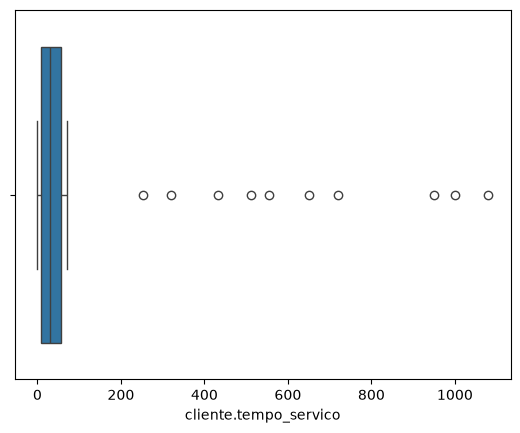

In [26]:
sns.boxplot(x = dados_sem_vazio['cliente.tempo_servico'])

In [27]:
Q1 = dados_sem_vazio['cliente.tempo_servico'].quantile(.25)
Q3 = dados_sem_vazio['cliente.tempo_servico'].quantile(.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5*IQR
limite_superior = Q3 + 1.5*IQR

Substituindo valores para os outliers